# Importação de base

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import os
import warnings
warnings.filterwarnings('ignore')
!pip freeze | grep -iE "^(pandas|numpy|scikit-learn|matplotlib|seaborn|scipy)=="

matplotlib==3.10.0
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
scipy==1.16.3
seaborn==0.13.2


In [2]:
# ─── Configurações visuais ────────────────────────────────────────────────────
C0 = "#2ecc71"   # Adimplente
C1 = "#e74c3c"   # Inadimplente
BG = "#f8f9fa"
ACCENT = "#2c3e50"
OUT = "graficos_correlacao/"

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': BG,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

os.makedirs(OUT, exist_ok=True)

from google.colab import files

---


uploaded = files.upload()

In [3]:
# obs: para criar um token e ver seu nome de usuário acesse https://www.kaggle.com/settings
!pip install opendatasets

import opendatasets
opendatasets.download('https://www.kaggle.com/datasets/yasserh/loan-default-dataset')
df = pd.read_csv('loan-default-dataset/Loan_Default.csv')


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: pedroviniciusjustino
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/yasserh/loan-default-dataset


100%|██████████| 4.89M/4.89M [00:00<00:00, 127MB/s]

# Primeira análise

In [ ]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [ ]:

cols = ['income', 'dtir1', 'loan_amount', 'Credit_Score', 'LTV']


stats = df[cols].describe().T


stats['variancia'] = df[cols].var()
stats['assimetria'] = df[cols].skew()
stats['curtose'] = df[cols].kurt()
stats['IQR'] = stats['75%'] - stats['25%']
print(stats)

                 count           mean            std           min  \
income        139520.0    6957.338876    6496.586382      0.000000   
dtir1         124549.0      37.732932      10.545435      5.000000   
loan_amount   148670.0  331117.743997  183909.310127  16500.000000   
Credit_Score  148670.0     699.789103     115.875857    500.000000   
LTV           133572.0      72.746457      39.967603      0.967478   

                       25%           50%            75%         max  \
income          3720.00000    5760.00000    8520.000000   578580.00   
dtir1             31.00000      39.00000      45.000000       61.00   
loan_amount   196500.00000  296500.00000  436500.000000  3576500.00   
Credit_Score     599.00000     699.00000     800.000000      900.00   
LTV               60.47486      75.13587      86.184211     7831.25   

                 variancia  assimetria       curtose           IQR  
income        4.220563e+07   17.307695    885.292460    4800.00000  
dtir1         

<Axes: >

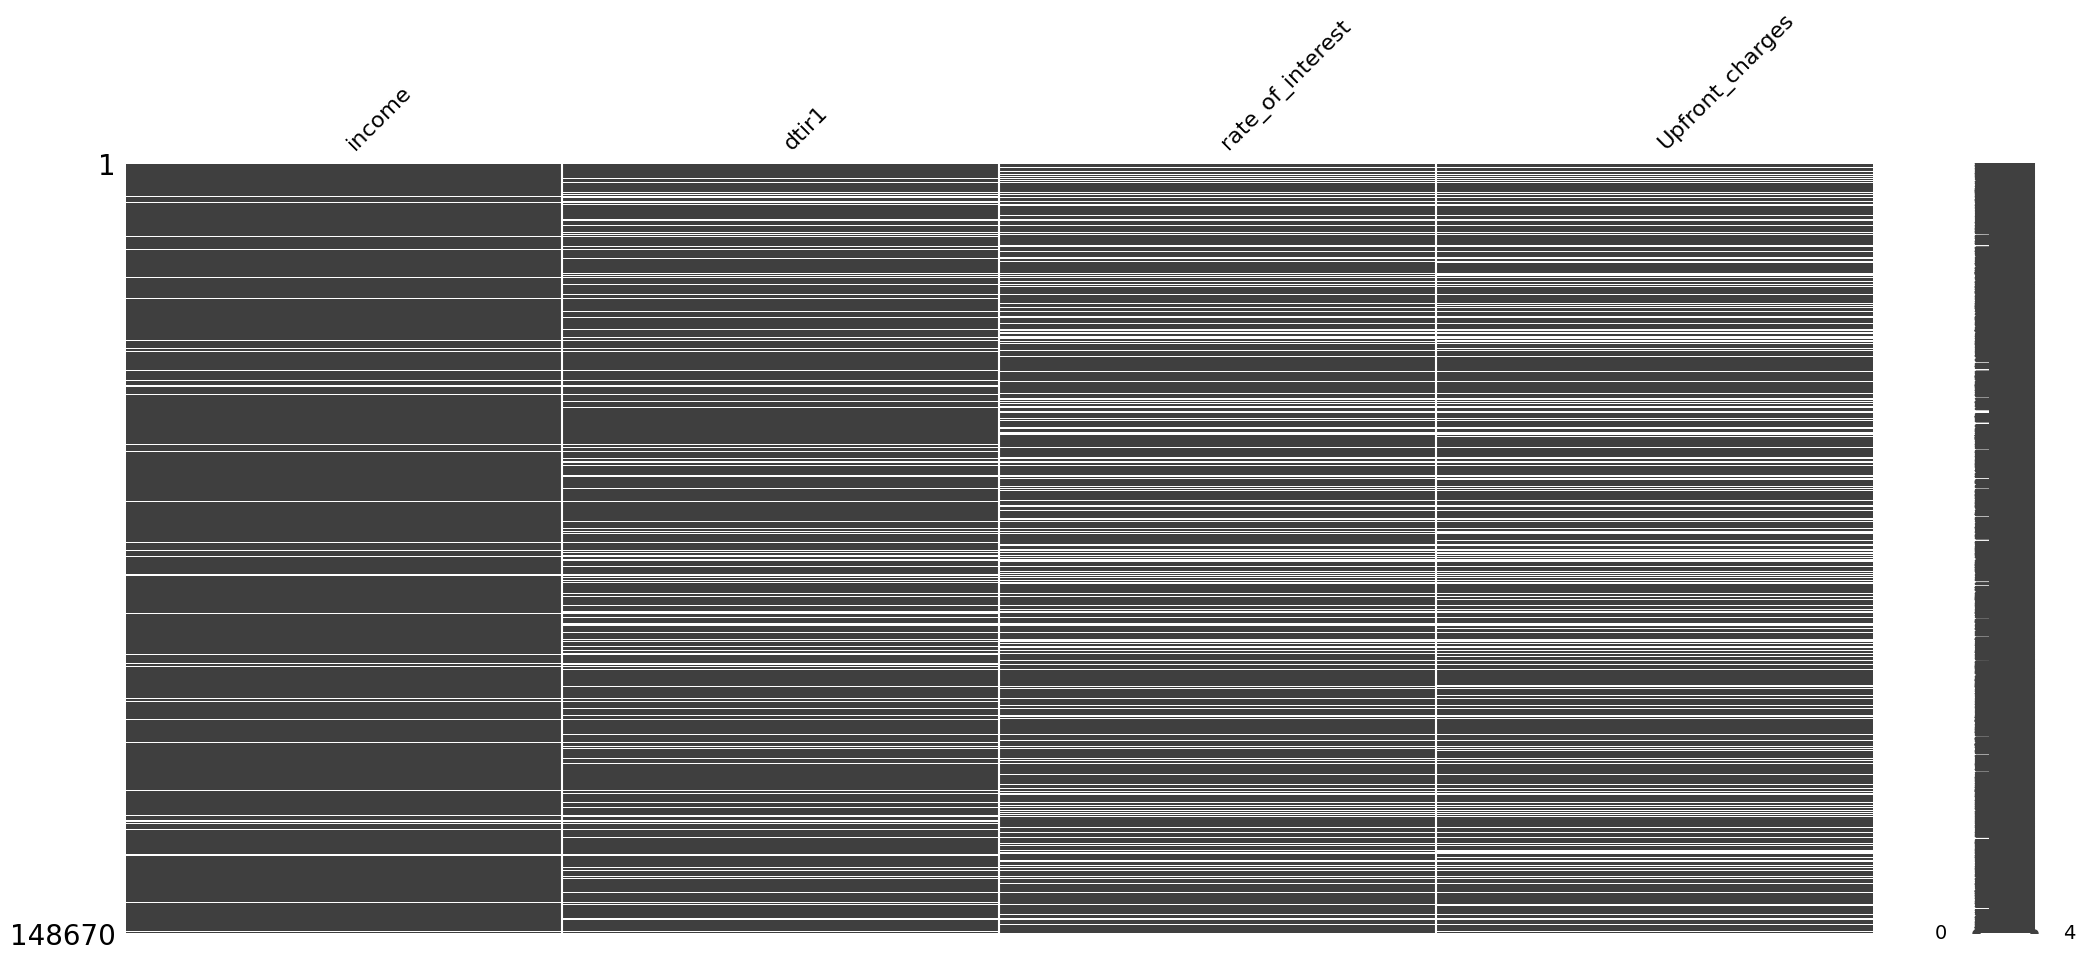

In [ ]:
import missingno as msno
msno.matrix(df[['income', 'dtir1', 'rate_of_interest', 'Upfront_charges']])

In [ ]:
df_inadimplentes = df[df['Status'] == 1]

faltantes_por_linha = df_inadimplentes.isnull().sum(axis=1)

# linhas que têm MAIS de 5 dados faltantes
casos_criticos = faltantes_por_linha[faltantes_por_linha > 5]


total_inadimplentes = len(df_inadimplentes)
qtd_casos_criticos = len(casos_criticos)
percentual = (qtd_casos_criticos / total_inadimplentes) * 100

print(f"--- ANÁLISE DE INADIMPLÊNCIA VS. DADOS AUSENTES ---")
print(f"Total de casos de inadimplência no dataset: {total_inadimplentes}")
print(f"Casos de inadimplência com > 5 colunas faltantes: {qtd_casos_criticos}")
print(f"Isso representa {percentual:.2f}% de todos os inadimplentes.")

--- ANÁLISE DE INADIMPLÊNCIA VS. DADOS AUSENTES ---
Total de casos de inadimplência no dataset: 36639
Casos de inadimplência com > 5 colunas faltantes: 15163
Isso representa 41.38% de todos os inadimplentes.


In [ ]:

colunas_criticas = [
    'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges',
    'property_value', 'LTV', 'dtir1', 'income'
]

print("DADOS AUSENTES (STATUS 1 / TOTAL NULOS)")

for col in colunas_criticas:

    df_nulos_coluna = df[df[col].isnull()]

    total_nulos = len(df_nulos_coluna)

    if total_nulos > 0:
        qtd_status_1 = df_nulos_coluna['Status'].sum()
        percentual = (qtd_status_1 / total_nulos) * 100

        print(f"Coluna: {col:22} | Nulos: {total_nulos:6} | Inadimplentes: {percentual:6.2f}%")

DADOS AUSENTES (STATUS 1 / TOTAL NULOS)
Coluna: rate_of_interest       | Nulos:  36439 | Inadimplentes: 100.00%
Coluna: Interest_rate_spread   | Nulos:  36639 | Inadimplentes: 100.00%
Coluna: Upfront_charges        | Nulos:  39642 | Inadimplentes:  92.04%
Coluna: property_value         | Nulos:  15098 | Inadimplentes:  99.99%
Coluna: LTV                    | Nulos:  15098 | Inadimplentes:  99.99%
Coluna: dtir1                  | Nulos:  24121 | Inadimplentes:  67.62%
Coluna: income                 | Nulos:   9150 | Inadimplentes:  13.54%


In [ ]:
total_inadimplentes = (df['Status'] == 1).sum()


colunas_analise = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges',
    'property_value', 'LTV', 'dtir1', 'income']

print(f"Total de casos de inadimplência (Status 1): {total_inadimplentes}\n")
print(f"{'Coluna':<20} | {'Nulos no Status 1':<18} | {'% do Total de Calotes'}")
print("-" * 65)

for col in colunas_analise:

    nulos_no_status_1 = df[df[col].isnull() & (df['Status'] == 1)].shape[0]

    porcentagem_do_calote = (nulos_no_status_1 / total_inadimplentes) * 100

    print(f"{col:<20} | {nulos_no_status_1:<18} | {porcentagem_do_calote:>18.2f}%")

Total de casos de inadimplência (Status 1): 36639

Coluna               | Nulos no Status 1  | % do Total de Calotes
-----------------------------------------------------------------
rate_of_interest     | 36439              |              99.45%
Interest_rate_spread | 36639              |             100.00%
Upfront_charges      | 36486              |              99.58%
property_value       | 15096              |              41.20%
LTV                  | 15096              |              41.20%
dtir1                | 16310              |              44.52%
income               | 1239               |               3.38%


In [ ]:
nulos_combinados = df[df['rate_of_interest'].isnull() & df['income'].isnull()].shape[0]

print(f"Total de linhas onde Taxa e Renda são nulos: {nulos_combinados}")

Total de linhas onde Taxa e Renda são nulos: 1039


In [ ]:
nulos_combinados = df[df['rate_of_interest'].isnull() & df['dtir1'].isnull()].shape[0]

print(f"Total de linhas onde ambos Taxa e divida são nulos: {nulos_combinados}")

Total de linhas onde ambos Taxa e divida são nulos: 16110


In [ ]:

intersecoes = {
    'Renda (income)': df[df['rate_of_interest'].isnull() & df['income'].isnull()].shape[0],
    'DTI (dtir1)': df[df['rate_of_interest'].isnull() & df['dtir1'].isnull()].shape[0],
    'Valor Imóvel (property_value)': df[df['rate_of_interest'].isnull() & df['property_value'].isnull()].shape[0],
    'LTV': df[df['rate_of_interest'].isnull() & df['LTV'].isnull()].shape[0]
}

print("--- Quantos nulos em 'rate_of_interest' também são nulos em: ---")
for col, valor in intersecoes.items():
    print(f"{col}: {valor} linhas")


--- Quantos nulos em 'rate_of_interest' também são nulos em: ---
Renda (income): 1039 linhas
DTI (dtir1): 16110 linhas
Valor Imóvel (property_value): 15096 linhas
LTV: 15096 linhas


In [ ]:
filtro_vazio_total = (
    df['rate_of_interest'].isnull() &
    df['property_value'].isnull() &
    df['LTV'].isnull()
)

# Isolamos essas linhas
df_conjunto_faltante = df[filtro_vazio_total]

# Calculamos a quantidade e a proporção de inadimplentes (Status 1)
total_linhas = df_conjunto_faltante.shape[0]
qtd_status_1 = df_conjunto_faltante['Status'].sum()
percentual = (qtd_status_1 / total_linhas) * 100

print(f"Total de linhas com as 3 colunas nulas: {total_linhas}")
print(f"Status 1 (Inadimplente): {qtd_status_1}")
print(f"Percentual de Inadimplência nesse grupo: {percentual:.2f}%")

Total de linhas com as 3 colunas nulas: 15096
Status 1 (Inadimplente): 15096
Percentual de Inadimplência nesse grupo: 100.00%


# Limpeza e definição do pipeline


In [7]:
df_clean = df[
    ((df['income'] > 0) | (df['income'].isnull())) &
    ((df['dtir1'] >= 0) | (df['dtir1'].isnull()))
].copy()

print(f"Base inicial de limpeza criada com {len(df_clean)} linhas.")

Base inicial de limpeza criada com 147410 linhas.


In [8]:

df_clean['processo_interrompido'] = np.where(
    (df_clean['rate_of_interest'].isnull()) |
    (df_clean['property_value'].isnull()) |
    (df_clean['Interest_rate_spread'].isnull()) |
    (df_clean['LTV'].isnull()) |
    (df_clean['Upfront_charges'].isnull()),
    1, 0
)

print(f"Total de registros após a limpeza: {df_clean.shape[0]}")
print(df_clean['processo_interrompido'].value_counts())

Total de registros após a limpeza: 147410
processo_interrompido
0    108875
1     38535
Name: count, dtype: int64


In [9]:


cols_mediana_simples = ['term', 'age', 'submission_of_application']
for col in cols_mediana_simples:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    else:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())


cols_moda = ['loan_limit', 'approv_in_adv', 'loan_purpose', 'Neg_ammortization']
for col in cols_moda:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import pandas as pd


colunas_para_remover = [
 'Status', 'processo_interrompido', 'rate_of_interest',
    'Interest_rate_spread', 'Upfront_charges', 'property_value', 'LTV', 'year', 'ID'
]

X = df_clean.drop(columns=colunas_para_remover)
y = df_clean['Status']

X_encoded = pd.get_dummies(X, drop_first=True)


# SEPARAÇÃO EM TREINO E TESTE

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)


# DETECÇÃO DE NULOS NO CONJUNTO DE TREINO

colunas_mice_treino = X_train.columns[X_train.isnull().any()].tolist()

print("\n--- DETECÇÃO DE COLUNAS COM NULOS ---")
print(f"Colunas que passarão pelo MICE: {colunas_mice_treino}\n")


# CONFIGURAÇÃO DA ARQUITETURA DE PRÉ-PROCESSAMENTO E PIPELINE

precomputacao = ColumnTransformer(
    transformers=[
        ('mice_imputer', IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=10, max_depth=10, n_jobs=-1, random_state=42),
            max_iter=5,
            random_state=42
        ), colunas_mice_treino)
    ],
    remainder='passthrough'
)

precomputacao.set_output(transform="pandas")

# Criando o Pipeline final
pipeline_final = Pipeline(steps=[
    ('pre-processamento', precomputacao),
    ('modelo', RandomForestClassifier(
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=1,
        max_depth=30,
        criterion='gini',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])


# TREINAMENTO SEGURO
pipeline_final.fit(X_train, y_train)
print("Treinamento concluído com sucesso!")


--- DETECÇÃO DE COLUNAS COM NULOS ---
Colunas que passarão pelo MICE: ['income', 'dtir1']

Treinamento concluído com sucesso!


In [14]:
pipeline_final.fit(X_train, y_train)

Pipeline(steps=[('pre-processamento',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('mice_imputer',
                                                  IterativeImputer(estimator=RandomForestRegressor(max_depth=10,
                                                                                                   n_estimators=10,
                                                                                                   n_jobs=-1,
                                                                                                   random_state=42),
                                                                   max_iter=5,
                                                                   random_state=42),
                                                  ['income', 'dtir1'])])),
                ('modelo',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=30, min_samples_split=10,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

# Random Forest Classifier

In [ ]:
from sklearn.metrics import classification_report

y_pred_final = pipeline_final.predict(X_test)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92     22405
           1       0.83      0.60      0.69      7077

    accuracy                           0.87     29482
   macro avg       0.86      0.78      0.81     29482
weighted avg       0.87      0.87      0.87     29482



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# 1. Isolamento dos dados e remoção de data leakage
colunas_para_remover = [
    'Status', 'processo_interrompido', 'rate_of_interest',
    'Interest_rate_spread', 'Upfront_charges', 'property_value', 'LTV', 'year', 'ID'
]

X = df_clean.drop(columns=colunas_para_remover)
y = df_clean['Status']

# Mapeamento de colunas para o pré-processamento
colunas_numericas = ['income', 'dtir1', 'Credit_Score']

# One-hot encoding das variáveis categóricas
X_encoded = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Estruturação do ColumnTransformer
precomputacao_rf = ColumnTransformer(
    transformers=[
        ('mice_num', IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=10, max_depth=10, n_jobs=-1, random_state=42),
            max_iter=5, random_state=42
        ), colunas_numericas)
    ],
    remainder='passthrough'
)
precomputacao_rf.set_output(transform="pandas")

# 3. Construção do Pipeline Base do Random Forest
pipeline_rf = Pipeline(steps=[
    ('pre-processamento', precomputacao_rf),
    ('modelo', RandomForestClassifier(random_state=42, n_jobs=-1))
])

print("Dados divididos e Pipeline estruturado ")

Dados divididos e Pipeline estruturado 


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Definição do dicionário unificado de hiperparâmetros
param_dist = {
    'modelo__n_estimators': [100, 200, 300, 400],
    'modelo__max_depth': [10, 20, 30, None],
    'modelo__min_samples_split': [2, 5, 10, 15],
    'modelo__min_samples_leaf': [1, 2, 4],
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__class_weight': ['balanced', 'balanced_subsample', None]
}

# Configuração da busca automatizada
random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=30,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

print("Iniciando a busca unificada por hiperparâmetros sobre o conjunto de treino...")
random_search_rf.fit(X_train, y_train)
print("Busca concluída")

Iniciando a busca unificada por hiperparâmetros sobre o conjunto de treino...
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Busca concluída


In [ ]:
print(f"Melhor PR-AUC Média na Validação Cruzada: {random_search_rf.best_score_:.4f}\n")
print("Combinação de  melhores parâmetros:")

for parametro, valor in random_search_rf.best_params_.items():

    nome_limpo = parametro.replace('modelo__', '')
    print(f"  • {nome_limpo}: {valor}")

melhor_pipeline_rf = random_search_rf.best_estimator_

Melhor PR-AUC Média na Validação Cruzada: 0.7956

Combinação de  melhores parâmetros:
  • n_estimators: 300
  • min_samples_split: 10
  • min_samples_leaf: 2
  • max_depth: 20
  • criterion: gini
  • class_weight: None


In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

y_scores_rf = melhor_pipeline_rf.predict_proba(X_test)[:, 1]

y_pred_rf = melhor_pipeline_rf.predict(X_test)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores_rf)

pr_auc_teste = auc(recalls, precisions)


print("RELATÓRIO DE PERFORMANCE FINAL (CONJUNTO DE TESTE)")
print(f"PR-AUC Final Legítima no Teste: {pr_auc_teste:.4f}")
print("\nRelatório de Classificação Completo:")
print(classification_report(y_test, y_pred_rf))

RELATÓRIO DE PERFORMANCE FINAL (CONJUNTO DE TESTE)
PR-AUC Final Legítima no Teste: 0.7948

Relatório de Classificação Completo:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93     22405
           1       0.93      0.53      0.68      7077

    accuracy                           0.88     29482
   macro avg       0.90      0.76      0.80     29482
weighted avg       0.89      0.88      0.87     29482



In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# 1. Predição de probabilidades e classes no conjunto de TREINO
y_scores_train_rf = melhor_pipeline_rf.predict_proba(X_train)[:, 1]
y_pred_train_rf = melhor_pipeline_rf.predict(X_train)

# 2. Cálculo da PR-AUC de Treino
prec_tr_rf, rec_tr_rf, _ = precision_recall_curve(y_train, y_scores_train_rf)
pr_auc_train_rf = auc(rec_tr_rf, prec_tr_rf)

print("====================================================")
print(" RELATÓRIO DE PERFORMANCE - TREINO (RANDOM FOREST) ")
print("====================================================")
print(f"PR-AUC no Treino: {pr_auc_train_rf:.4f}")
print("\nRelatório de Classificação (Treino):")
print(classification_report(y_train, y_pred_train_rf))

 RELATÓRIO DE PERFORMANCE - TREINO (RANDOM FOREST) 
PR-AUC no Treino: 0.8905

Relatório de Classificação (Treino):
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     89618
           1       0.98      0.59      0.73     28310

    accuracy                           0.90    117928
   macro avg       0.93      0.79      0.83    117928
weighted avg       0.91      0.90      0.89    117928



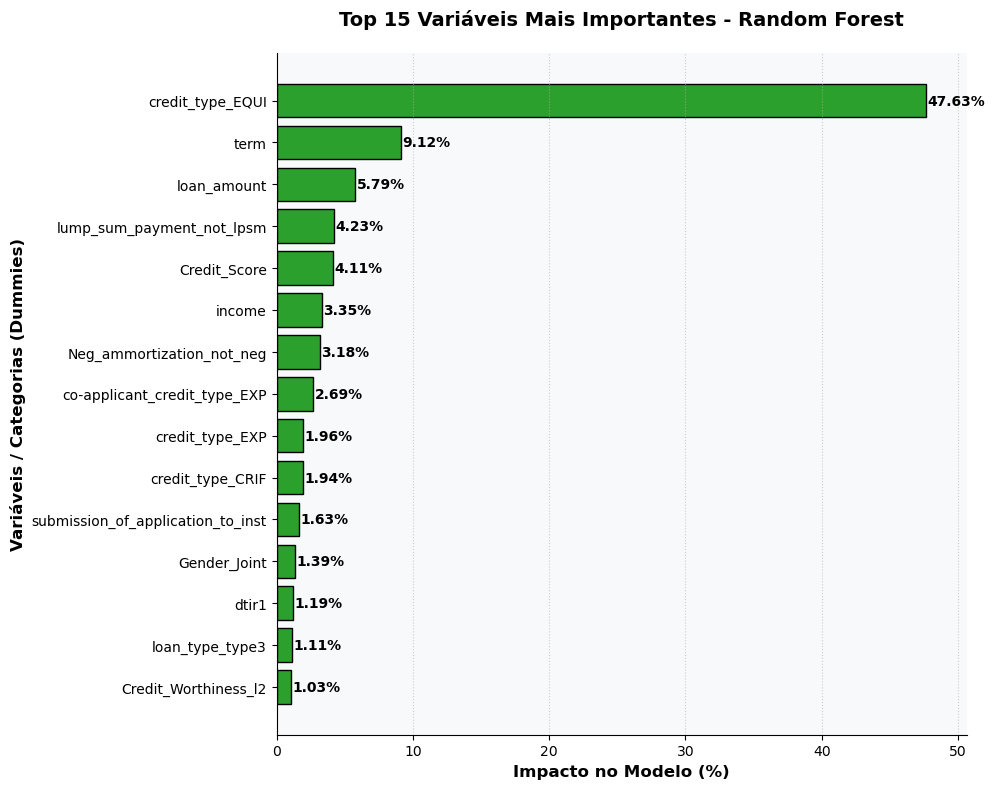

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extrair as importâncias direto do modelo dentro do pipeline do Random Forest
importancias_rf = melhor_pipeline_rf.named_steps['modelo'].feature_importances_ * 100


nomes_colunas_rf = X_train.columns.tolist()

# 3. Criar o DataFrame e ordenar
df_importancia_rf = pd.DataFrame({
    'Atributo': nomes_colunas_rf,
    'Porcentagem (%)': importancias_rf
}).sort_values(by='Porcentagem (%)', ascending=True)

# 4. Selecionar apenas as Top 15

df_top_rf = df_importancia_rf.tail(15)


plt.figure(figsize=(10, 8))
barras = plt.barh(df_top_rf['Atributo'], df_top_rf['Porcentagem (%)'], color='#2ca02c', edgecolor='black')

# Adicionar as tags de porcentagem nas pontas das barras
for barra in barras:
    largura = barra.get_width()
    if largura > 0.5:
        plt.text(
            largura + 0.1,
            barra.get_y() + barra.get_height()/2,
            f'{largura:.2f}%',
            va='center', ha='left', fontsize=10, fontweight='bold'
        )


plt.title('Top 15 Variáveis Mais Importantes - Random Forest', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Impacto no Modelo (%)', fontsize=12, fontweight='bold')
plt.ylabel('Variáveis / Categorias (Dummies)', fontsize=12, fontweight='bold')
plt.xlim(0, df_top_rf['Porcentagem (%)'].max() + 3)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Regressão Logística final


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


# Descartando as colunas com vazamento ou excesso de nulos conhecidas
colunas_para_remover = [
    'Status', 'processo_interrompido', 'rate_of_interest',
    'Interest_rate_spread', 'Upfront_charges', 'property_value', 'LTV', 'year', 'ID'
]

X = df_clean.drop(columns=colunas_para_remover)
y = df_clean['Status']

# SEPARAÇÃO TREINO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# MAPEAMENTO DE COLUNAS

colunas_numericas = ['income', 'dtir1', 'Credit_Score']
colunas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


# CRIAÇÃO DAS ESTEIRAS ESPECÍFICAS

esteira_numerica = Pipeline(steps=[
    ('mice_imputer', IterativeImputer(
        estimator=RandomForestRegressor(n_estimators=10, max_depth=10, n_jobs=-1, random_state=42),
        max_iter=5, random_state=42
    )),
    ('scaler', StandardScaler())
])

esteira_categorica = Pipeline(steps=[
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])


# PRÉ-PROCESSAMENTO COMPLETO

precomputacao = ColumnTransformer(
    transformers=[
        ('num', esteira_numerica, colunas_numericas),
        ('cat', esteira_categorica, colunas_categoricas)
    ],
    remainder='drop'  # Garante que nada extra ou não mapeado passe para o modelo
)
precomputacao.set_output(transform="pandas")


# 5. ESTRUTURAÇÃO DA ESTEIRA FINAL DA REGRESSÃO LOGÍSTICA

pipeline_logistica_final = Pipeline(steps=[
    ('pre-processamento', precomputacao),
    ('modelo', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        solver='saga',
        random_state=42,
        n_jobs=-1
    ))
])
pipeline_logistica_final.fit(X_train, y_train)

,steps,"[('pre-processamento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'modelo__C': [0.01, 0.1, 1.0, 10.0],
    'modelo__penalty': ['l1', 'l2'],
    'modelo__class_weight': ['balanced', None]
}

grid_search_lr = GridSearchCV(
    estimator=pipeline_logistica_final,
    param_grid=param_grid_lr,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    verbose=2
)


print("Iniciando o Grid Search")
grid_search_lr.fit(X_train, y_train)
print("Grid Search concluído!")

Iniciando o Grid Search
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Grid Search concluído!


In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Resgata o melhor pipeline
melhor_pipeline_lr = grid_search_lr.best_estimator_

# Predição de probabilidades e classes usando o X_test
y_scores_lr = melhor_pipeline_lr.predict_proba(X_test)[:, 1]
y_pred_lr = melhor_pipeline_lr.predict(X_test)


precisions_lr, recalls_lr, _ = precision_recall_curve(y_test, y_scores_lr)
pr_auc_teste_lr = auc(recalls_lr, precisions_lr)


print("MELHORES HIPERPARAMETROS ENCONTRADOS")

print(f"Melhor PR-AUC na Validação Cruzada: {grid_search_lr.best_score_:.4f}\n")
for k, v in grid_search_lr.best_params_.items():
    print(f"  • {k.split('__')[-1]}: {v}")



MELHORES HIPERPARAMETROS ENCONTRADOS
Melhor PR-AUC na Validação Cruzada: 0.7430

  • C: 10.0
  • class_weight: None
  • penalty: l1


In [ ]:
print("PERFORMANCE NO TESTE FINAL")
print(f"PR-AUC Final no Teste: {pr_auc_teste_lr:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_lr))

PERFORMANCE NO TESTE FINAL
PR-AUC Final no Teste: 0.7397

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92     22405
           1       0.93      0.47      0.62      7077

    accuracy                           0.86     29482
   macro avg       0.89      0.73      0.77     29482
weighted avg       0.87      0.86      0.85     29482



In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# 1. Predição de probabilidades e classes no conjunto de TREINO
y_scores_train_lr = melhor_pipeline_lr.predict_proba(X_train)[:, 1]
y_pred_train_lr = melhor_pipeline_lr.predict(X_train)

# 2. Cálculo da PR-AUC de Treino
prec_tr_lr, rec_tr_lr, _ = precision_recall_curve(y_train, y_scores_train_lr)
pr_auc_train_lr = auc(rec_tr_lr, prec_tr_lr)

print("====================================================")
print("RELATÓRIO DE PERFORMANCE - TREINO (REGRESSÃO LOGÍSTICA) ")
print("====================================================")
print(f"PR-AUC no Treino: {pr_auc_train_lr:.4f}")
print("\nRelatório de Classificação (Treino):")
print(classification_report(y_train, y_pred_train_lr))

RELATÓRIO DE PERFORMANCE - TREINO (REGRESSÃO LOGÍSTICA) 
PR-AUC no Treino: 0.7435

Relatório de Classificação (Treino):
              precision    recall  f1-score   support

           0       0.85      0.99      0.92     89618
           1       0.94      0.47      0.62     28310

    accuracy                           0.86    117928
   macro avg       0.90      0.73      0.77    117928
weighted avg       0.87      0.86      0.85    117928



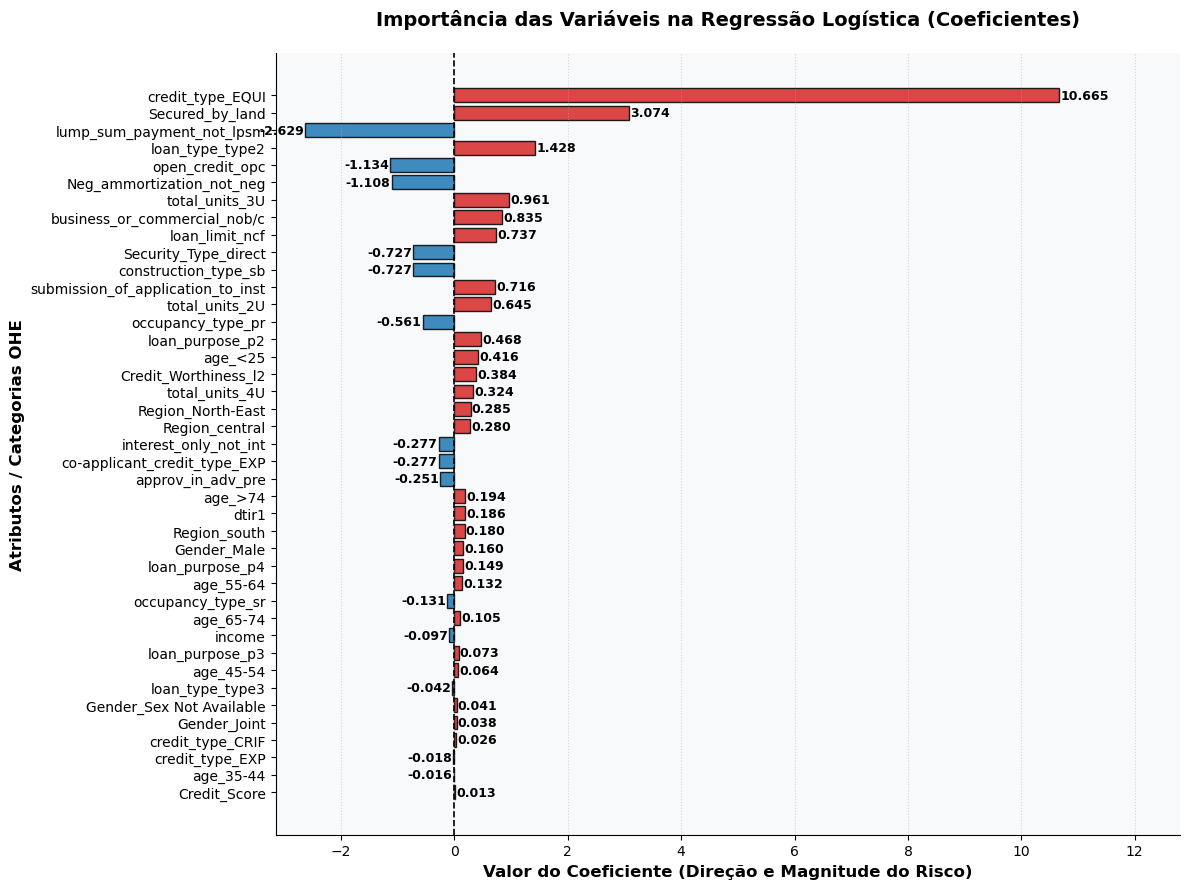

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extrair os coeficientes do modelo linear (primeira linha da matriz de pesos)
coeficientes = melhor_pipeline_lr.named_steps['modelo'].coef_[0]

# 2. Extrair os nomes exatos das colunas geradas pelo seu ColumnTransformer (num + cat)
nomes_colunas_transformadas = melhor_pipeline_lr.named_steps['pre-processamento'].get_feature_names_out()

# Limpar os prefixos internos do scikit-learn (como 'num__num_tratado__' ou 'cat__encoder__')
nomes_limpos = [nome.split('__')[-1] for nome in nomes_colunas_transformadas]

# 3. Criar o DataFrame e ordenar pelo valor absoluto (magnitude do impacto)
df_coef = pd.DataFrame({
    'Atributo': nomes_limpos,
    'Coeficiente': coeficientes,
    'Magnitude': np.abs(coeficientes)
}).sort_values(by='Magnitude', ascending=True) # Ordena para o maior impacto ficar no topo do gráfico

# 4. Definir mapeamento de cores com base na direção do risco
# Coeficiente Positivo (Vermelho) -> Aumenta a probabilidade de calote
# Coeficiente Negativo (Azul)     -> Diminui a probabilidade de calote
cores = ['#d62728' if c > 0 else '#1f77b4' for c in df_coef['Coeficiente']]

# 5. Construção do Gráfico de Barras Horizontal
plt.figure(figsize=(12, 9), dpi=100)
barras = plt.barh(df_coef['Atributo'], df_coef['Coeficiente'], color=cores, edgecolor='black', alpha=0.85)

# Adicionar os valores numéricos correspondentes nas pontas de cada barra
for barra in barras:
    largura = barra.get_width()

    # Determina o espaçamento do texto dependendo se a barra aponta para a esquerda ou direita
    if largura >= 0:
        posicao_x = largura + 0.02
        alinhamento = 'left'
    else:
        posicao_x = largura - 0.02
        alinhamento = 'right'

    # Só plota o texto se o coeficiente não tiver sido zerado pelo Lasso (L1)
    if np.abs(largura) > 0.001:
        plt.text(
            posicao_x,
            barra.get_y() + barra.get_height()/2,
            f'{largura:.3f}',
            va='center', ha=alinhamento, fontsize=9, fontweight='bold'
        )

# Injeção da linha neutra de referência no ponto zero
plt.axvline(0, color='black', linewidth=1.2, linestyle='--')

# Customização técnica e limites dos eixos
plt.title('Importância das Variáveis na Regressão Logística (Coeficientes)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Valor do Coeficiente (Direção e Magnitude do Risco)', fontsize=12, fontweight='bold')
plt.ylabel('Atributos / Categorias OHE', fontsize=12, fontweight='bold')

limite_max = df_coef['Coeficiente'].max()
limite_min = df_coef['Coeficiente'].min()
plt.xlim(limite_min * 1.2, limite_max * 1.2) # Margem de segurança para os textos nas extremidades

plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# CatBoost


In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostClassifier

# Isolamento dos dados e remoção de data leakage
colunas_para_remover = [
    'Status', 'processo_interrompido', 'rate_of_interest',
    'Interest_rate_spread', 'Upfront_charges', 'property_value', 'LTV', 'year', 'ID'
]

X = df_clean.drop(columns=colunas_para_remover)
y = df_clean['Status']

# Mapeamento de colunas por tipo
colunas_numericas = ['income', 'dtir1', 'Credit_Score']
colunas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

for col in colunas_categoricas:
    X_train[col] = X_train[col].astype(str).fillna('missing')
    X_test[col] = X_test[col].astype(str).fillna('missing')

# Estruturação do ColumnTransformer
precomputacao_cat = ColumnTransformer(
    transformers=[
        ('mice_num', IterativeImputer(
            estimator=RandomForestRegressor(n_estimators=10, max_depth=10, n_jobs=-1, random_state=42),
            max_iter=5, random_state=42
        ), colunas_numericas)
    ],
    remainder='passthrough'
)
precomputacao_cat.set_output(transform="pandas")

# Mapeamento de Índices para as Categóricas
novas_colunas = colunas_numericas + [col for col in X_train.columns if col not in colunas_numericas]
indices_categoricos = [novas_colunas.index(col) for col in colunas_categoricas]

# Construção do Pipeline Base do CatBoost
pipeline_catboost = Pipeline(steps=[
    ('pre-processamento', precomputacao_cat),
    ('modelo', CatBoostClassifier(
        random_seed=42,
        thread_count=-1,
        verbose=False
    ))
])

print("Pipeline completo")


Pipeline completo


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_cat = {
    'modelo__cat_features': [indices_categoricos],
    'modelo__iterations': [100, 200, 300, 400],
    'modelo__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'modelo__depth': [4, 6, 8, 10],
    'modelo__l2_leaf_reg': [1, 3, 5, 10],
    'modelo__auto_class_weights': ['Balanced', 'SqrtBalanced', None]
}

random_search_cat = RandomizedSearchCV(
    estimator=pipeline_catboost,
    param_distributions=param_dist_cat,
    n_iter=50,
    scoring='average_precision',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

print("Iniciando a busca dos Hiperparametros do CatBoost")
random_search_cat.fit(X_train, y_train)
print("Busca concluída")

Iniciando a busca dos Hiperparametros do CatBoost
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Busca concluída


In [ ]:
print("MELHORES HIPERPARAMETROS DO CATBOOST NO TREINO ")
print(f"Melhor PR-AUC Média na Validação Cruzada: {random_search_cat.best_score_:.4f}\n")
print("Combinação de parâmetros:")

for parametro, valor in random_search_cat.best_params_.items():
    nome_limpo = parametro.replace('modelo__', '')
    print(f"  {nome_limpo}: {valor}")

melhor_pipeline_cat = random_search_cat.best_estimator_

MELHORES HIPERPARAMETROS DO CATBOOST NO TREINO 
Melhor PR-AUC Média na Validação Cruzada: 0.8045

Combinação de parâmetros:
  learning_rate: 0.05
  l2_leaf_reg: 5
  iterations: 300
  depth: 8
  cat_features: [3, 4, 5, 6, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
  auto_class_weights: SqrtBalanced


In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# 1. Predição de probabilidades para a classe 1 (Inadimplentes)
y_scores_cat = melhor_pipeline_cat.predict_proba(X_test)[:, 1]

# 2. Predição discreta (0 ou 1) para o relatório tradicional
y_pred_cat = melhor_pipeline_cat.predict(X_test)

# 3. Cálculo da PR-AUC real do teste
precisions_cat, recalls_cat, thresholds_cat = precision_recall_curve(y_test, y_scores_cat)
pr_auc_teste_cat = auc(recalls_cat, precisions_cat)

print("RELATÓRIO DE PERFORMANCE  (TESTE - CATBOOST)")
print(f"PR-AUC Final no Teste: {pr_auc_teste_cat:.4f}")
print("\nRelatório de Classificação Completo:")
print(classification_report(y_test, y_pred_cat))

RELATÓRIO DE PERFORMANCE  (TESTE - CATBOOST)
PR-AUC Final no Teste: 0.8030

Relatório de Classificação Completo:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     22405
           1       0.85      0.60      0.71      7077

    accuracy                           0.88     29482
   macro avg       0.87      0.78      0.81     29482
weighted avg       0.88      0.88      0.87     29482



In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# 1. Predição de probabilidades e classes no conjunto de TREINO
y_scores_train_cat = melhor_pipeline_cat.predict_proba(X_train)[:, 1]
y_pred_train_cat = melhor_pipeline_cat.predict(X_train)

# 2. Cálculo da PR-AUC de Treino
prec_tr_cat, rec_tr_cat, _ = precision_recall_curve(y_train, y_scores_train_cat)
pr_auc_train_cat = auc(rec_tr_cat, prec_tr_cat)

print("====================================================")
print("RELATÓRIO DE PERFORMANCE - TREINO (CATBOOST)")
print("====================================================")
print(f"PR-AUC no Treino: {pr_auc_train_cat:.4f}")
print("\nRelatório de Classificação (Treino):")
print(classification_report(y_train, y_pred_train_cat))

RELATÓRIO DE PERFORMANCE - TREINO (CATBOOST)
PR-AUC no Treino: 0.8181

Relatório de Classificação (Treino):
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     89618
           1       0.87      0.61      0.72     28310

    accuracy                           0.89    117928
   macro avg       0.88      0.79      0.83    117928
weighted avg       0.89      0.89      0.88    117928



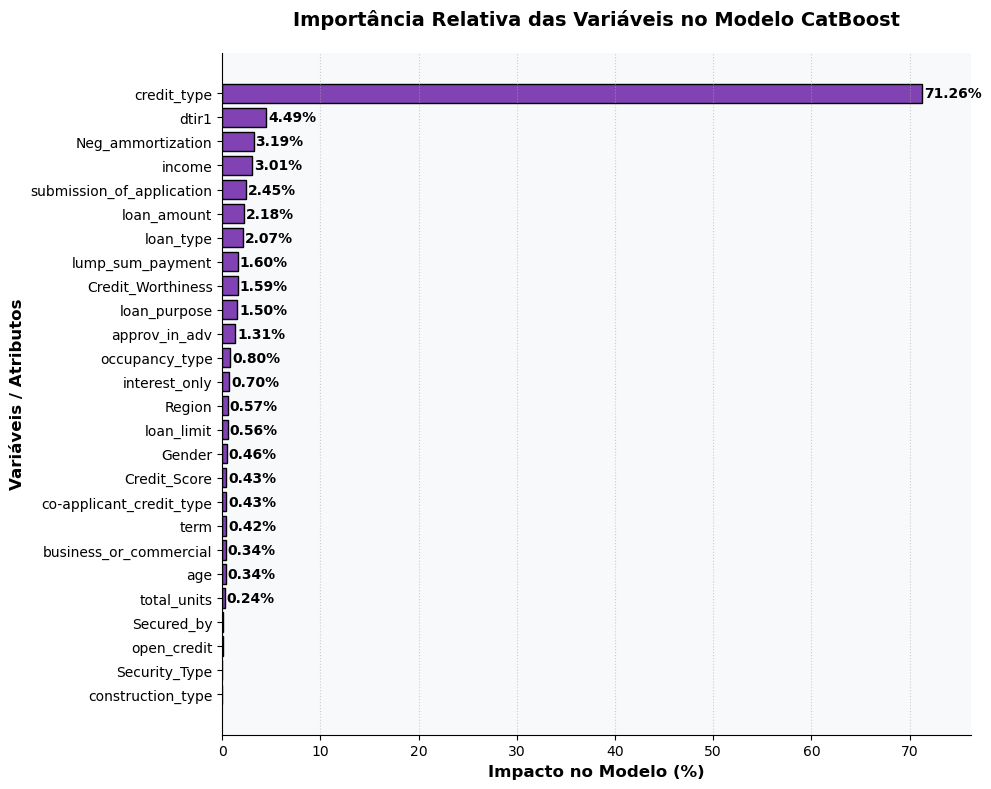

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


importancias = melhor_pipeline_cat.named_steps['modelo'].get_feature_importance()


nomes_colunas_transformadas = melhor_pipeline_cat.named_steps['pre-processamento'].get_feature_names_out()


nomes_limpos = [nome.split('__')[-1] for nome in nomes_colunas_transformadas]

# Criar o DataFrame!)
df_importancia = pd.DataFrame({
    'Atributo': nomes_limpos,
    'Porcentagem (%)': importancias
}).sort_values(by='Porcentagem (%)', ascending=True)


plt.figure(figsize=(10, 8))
barras = plt.barh(df_importancia['Atributo'], df_importancia['Porcentagem (%)'], color='#8142b3', edgecolor='black')


for barra in barras:
    largura = barra.get_width()
    if largura > 0.1:
        plt.text(
            largura + 0.2,
            barra.get_y() + barra.get_height()/2,
            f'{largura:.2f}%',
            va='center', ha='left', fontsize=10, fontweight='bold'
        )


plt.title('Importância Relativa das Variáveis no Modelo CatBoost', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Impacto no Modelo (%)', fontsize=12, fontweight='bold')
plt.ylabel('Variáveis / Atributos', fontsize=12, fontweight='bold')
plt.xlim(0, df_importancia['Porcentagem (%)'].max() + 5)
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Comparação


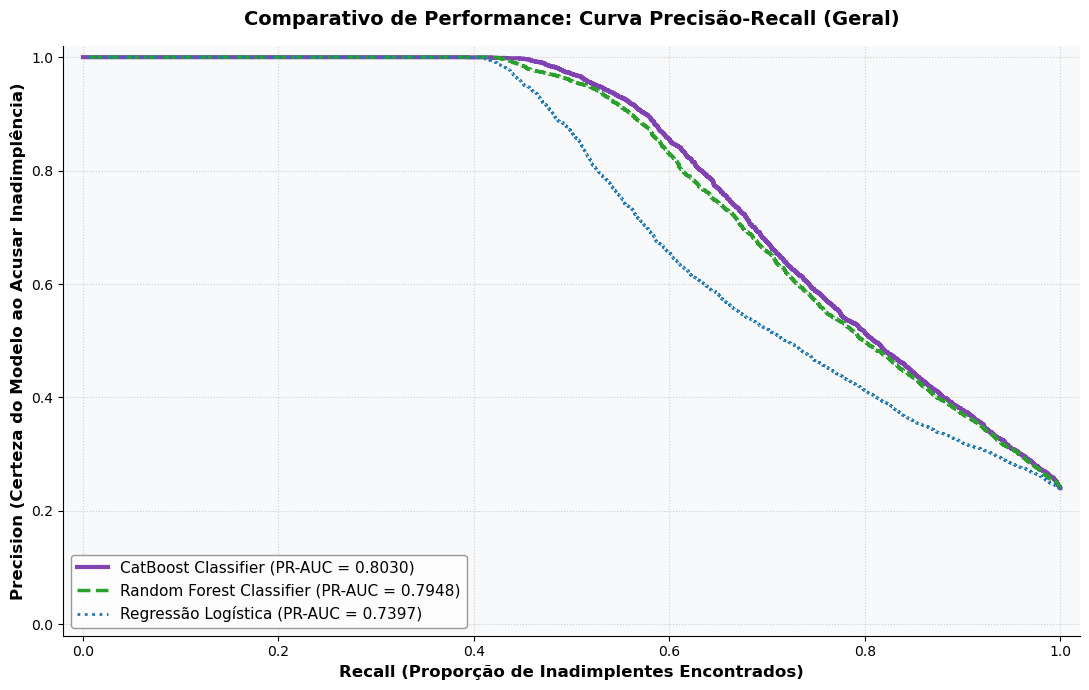

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# 1. Calcular os pontos da curva para cada modelo
prec_cat, rec_cat, _ = precision_recall_curve(y_test, y_scores_cat)
pr_auc_cat = auc(rec_cat, prec_cat)

prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_scores_rf)
pr_auc_rf = auc(rec_rf, prec_rf)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_scores_lr)
pr_auc_lr = auc(rec_lr, prec_lr)

# 2. Plotar as curvas no mesmo gráfico
plt.figure(figsize=(11, 7), dpi=100)

plt.plot(rec_cat, prec_cat, color='#8142b3', lw=3,
         label=f'CatBoost Classifier (PR-AUC = {pr_auc_cat:.4f})')

plt.plot(rec_rf, prec_rf, color='#2ca02c', lw=2.5, linestyle='--',
         label=f'Random Forest Classifier (PR-AUC = {pr_auc_rf:.4f})')

plt.plot(rec_lr, prec_lr, color='#1f77b4', lw=2, linestyle=':',
         label=f'Regressão Logística (PR-AUC = {pr_auc_lr:.4f})')

# Customização estética
plt.title('Comparativo de Performance: Curva Precisão-Recall (Geral)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recall (Proporção de Inadimplentes Encontrados)', fontsize=12, fontweight='bold')
plt.ylabel('Precision (Certeza do Modelo ao Acusar Inadimplência)', fontsize=12, fontweight='bold')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', fontsize=11, frameon=True, facecolor='white', edgecolor='gray')

plt.tight_layout()
plt.show()

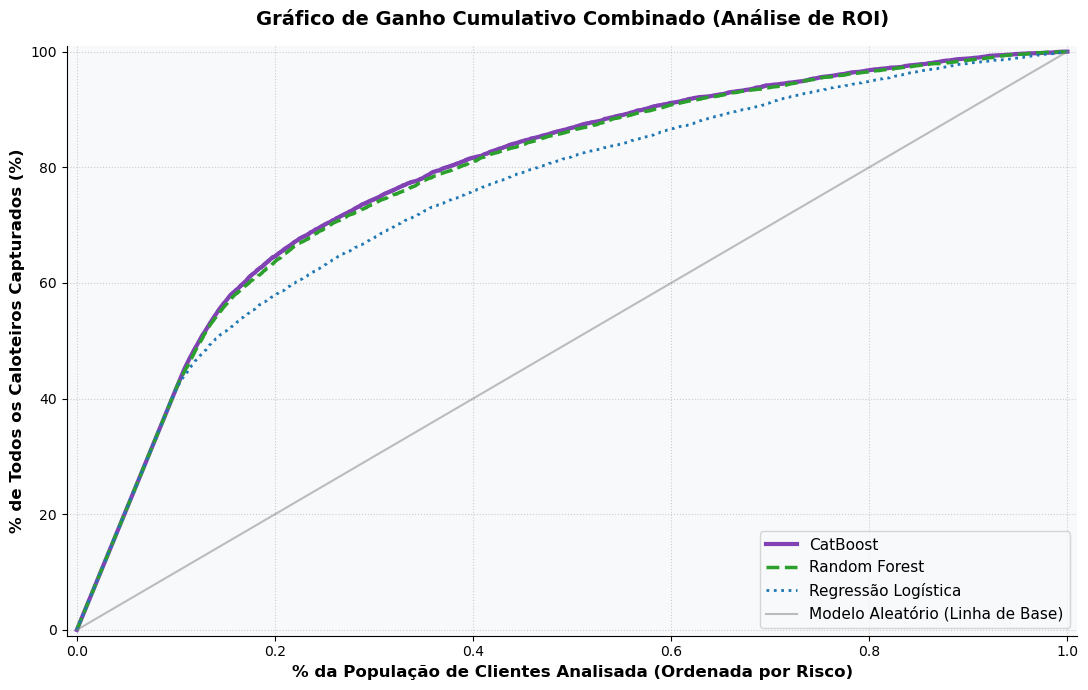

In [ ]:
import pandas as pd
import numpy as np

# Função interna para calcular o ganho cumulativo na unha de forma robusta
def calcular_ganho_cumulativo(y_true, y_probs):
    df_temp = pd.DataFrame({'real': y_true, 'prob': y_probs})
    # Ordena do maior risco (maior probabilidade de calote) para o menor
    df_temp = df_temp.sort_values(by='prob', ascending=False).reset_index(drop=True)

    # Calcula os acúmulos percentuais
    df_temp['total_inadimplentes_vistos'] = df_temp['real'].cumsum()
    total_inadimplentes_da_base = df_temp['real'].sum()

    ganho_acumulado = df_temp['total_inadimplentes_vistos'] / total_inadimplentes_da_base
    porcentagem_populacao = (df_temp.index + 1) / len(df_temp)

    # Força o ponto zero na largada do gráfico
    return np.insert(porcentagem_populacao.values, 0, 0), np.insert(ganho_acumulado.values, 0, 0)

# 1. Obter as curvas de ganho para os 3 modelos
pop_cat, ganho_cat = calcular_ganho_cumulativo(y_test.values, y_scores_cat)
pop_rf, ganho_rf = calcular_ganho_cumulativo(y_test.values, y_scores_rf)
pop_lr, ganho_lr = calcular_ganho_cumulativo(y_test.values, y_scores_lr)

# 2. Construção do Gráfico de Negócios
plt.figure(figsize=(11, 7), dpi=100)

plt.plot(pop_cat, ganho_cat * 100, color='#8142b3', lw=3, label='CatBoost')
plt.plot(pop_rf, ganho_rf * 100, color='#2ca02c', lw=2.5, linestyle='--', label='Random Forest')
plt.plot(pop_lr, ganho_lr * 100, color='#1f77b4', lw=2, linestyle=':', label='Regressão Logística')

# Linha de Base (Escolha Aleatória - Sem Modelo de Inteligência Artificial)
plt.plot([0, 1], [0, 100], color='gray', linestyle='-', alpha=0.5, label='Modelo Aleatório (Linha de Base)')

# Customização técnica para apresentação
plt.title('Gráfico de Ganho Cumulativo Combinado (Análise de ROI)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('% da População de Clientes Analisada (Ordenada por Risco)', fontsize=12, fontweight='bold')
plt.ylabel('% de Todos os Caloteiros Capturados (%)', fontsize=12, fontweight='bold')

plt.xlim([-0.01, 1.01])
plt.ylim([-1, 101])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)

plt.tight_layout()
plt.show()